# 21: FD003 short tuning

Objetivo: hacer una busqueda corta especifica para FD003 usando solo `train_FD003.txt`, validacion por motores completos y cortes artificiales. No se usa test oficial, no se carga `test_FD003.txt` ni `RUL_FD003.txt`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'CMAPSSData').exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

import sys
sys.path.append(str(PROJECT_ROOT))

from src.fd003_improvement_utils import (
    FD003_RANDOM_STATES,
    config_from_summary_row,
    ensure_fd003_dirs,
    evaluate_fd003_config_split,
    fd003_short_tuning_configs,
    save_json,
    select_best_summary_row,
    summarize_detail,
)

PATHS = ensure_fd003_dirs(PROJECT_ROOT)
DATA_DIR = PROJECT_ROOT / 'CMAPSSData'
RESULTS_DIR = PATHS['results']
FIGURES_DIR = PATHS['figures']
CONFIGS_DIR = PATHS['configs']
NOTES_DIR = PATHS['notes']
sns.set_theme(style='whitegrid')


## Busqueda acotada

Se prueba un subconjunto estratificado de configuraciones que cubre `window_size`, `rul_cap`, `objective`, `alpha` y `sample_weight_scheme`, sin convertirlo en un grid completo. La formula de `low_rul_weight` es: RUL<=30: 2.0; 30<RUL<=60: 1.5; 60<RUL<=100: 1.2; resto: 1.0.

In [2]:
configs = fd003_short_tuning_configs()
print('Configuraciones:', len(configs))
print('Splits:', FD003_RANDOM_STATES)


Configuraciones: 20
Splits: [0, 1, 2, 3, 4]


In [3]:
rows = []
for idx, config in enumerate(configs, start=1):
    print(f'Config {idx:02d}/{len(configs):02d}: {config["model_name"]}')
    for state in FD003_RANDOM_STATES:
        metrics, _, _ = evaluate_fd003_config_split(config, DATA_DIR, random_state=state)
        rows.append(metrics)

detail = pd.DataFrame(rows)
detail.to_csv(RESULTS_DIR / 'fd003_short_tuning_detail.csv', index=False)
group_cols = ['model_name', 'approach', 'window_size', 'rul_cap', 'objective', 'alpha', 'sample_weight_scheme', 'feature_set', 'n_features']
summary = summarize_detail(detail, group_cols)
summary = summary.sort_values(['mean_cmapss_score', 'mean_dangerous_error_pct', 'mean_rmse']).reset_index(drop=True)
summary.to_csv(RESULTS_DIR / 'fd003_short_tuning_summary.csv', index=False)
display(summary.head(10))


Config 01/20: fd003_lgbm_w30_cap125_quantile_a04_none


Config 02/20: fd003_lgbm_w30_cap125_quantile_a04_low_rul_weight


Config 03/20: fd003_lgbm_w30_cap125_regression_none


Config 04/20: fd003_lgbm_w50_cap125_quantile_a04_none


Config 05/20: fd003_lgbm_w50_cap125_quantile_a04_low_rul_weight


...

Config 17/20: fd003_lgbm_w50_cap125_quantile_a035_low_rul_weight


Config 18/20: fd003_lgbm_w50_cap125_quantile_a05_none


Config 19/20: fd003_lgbm_w50_cap125_quantile_a05_low_rul_weight


Config 20/20: fd003_lgbm_w50_cap125_regression_low_rul_weight


,model_name,approach,window_size,rul_cap,objective,alpha,sample_weight_scheme,feature_set,n_features,mean_mae,...,std_conservative_error_pct,mean_bias_mean,std_bias_mean,mean_abs_error_p90,std_abs_error_p90,mean_abs_error_p95,std_abs_error_p95,worst_rmse,worst_cmapss_score,worst_dangerous_error_pct
0,fd003_lgbm_w50_cap125_quantile_a04_none,short_tuning,50,125,quantile,0.40,none,base,140,12.079831,...,5.224940,-3.593095,2.766361,27.152507,4.401027,33.332152,3.240305,18.183572,555.049531,9.0
1,fd003_lgbm_w50_cap125_quantile_a035_none,short_tuning,50,125,quantile,0.35,none,base,140,12.373590,...,4.774935,-4.213362,2.632054,27.346326,3.344706,34.387836,4.305789,18.604164,647.099359,9.0
2,fd003_lgbm_w50_cap125_quantile_a04_low_rul_weight,short_tuning,50,125,quantile,0.40,low_rul_weight,base,140,12.218798,...,6.260990,-4.004318,2.869119,27.422958,2.306938,34.479076,4.075323,18.265591,586.099665,10.0
3,fd003_lgbm_w50_cap125_quantile_a05_low_rul_weight,short_tuning,50,125,quantile,0.50,low_rul_weight,base,140,12.278676,...,6.244998,-2.870495,3.137265,28.467378,2.790490,34.388032,4.040182,18.067969,495.443637,9.0
4,fd003_lgbm_w50_cap125_quantile_a035_low_rul_we...,short_tuning,50,125,quantile,0.35,low_rul_weight,base,140,12.258286,...,5.477226,-4.788509,2.867870,29.692924,5.046257,35.228149,6.020152,18.663321,584.365553,6.0
5,fd003_lgbm_w70_cap125_quantile_a04_none,short_tuning,70,125,quantile,0.40,none,base,140,12.795057,...,5.263079,-3.955282,2.771034,27.345807,2.190417,34.919206,4.701694,18.054129,495.518354,8.0
6,fd003_lgbm_w50_cap125_regression_low_rul_weight,short_tuning,50,125,regression,NaN,low_rul_weight,base,140,12.146759,...,5.549775,-2.463596,2.647509,27.197607,2.012674,33.981119,3.815622,17.921819,604.562052,9.0
7,fd003_lgbm_w50_cap125_regression_none,short_tuning,50,125,regression,NaN,none,base,140,12.288704,...,4.615192,-2.291128,2.608278,27.962742,1.661073,34.457174,3.126162,18.415593,755.583206,10.0
8,fd003_lgbm_w70_cap125_regression_none,short_tuning,70,125,regression,NaN,none,base,140,12.441064,...,4.324350,-2.888999,2.722151,26.428047,1.798656,33.448034,3.408997,18.895961,836.249856,10.0
9,fd003_lgbm_w70_cap125_quantile_a04_low_rul_weight,short_tuning,70,125,quantile,0.40,low_rul_weight,base,140,12.830155,...,4.472136,-4.549169,2.772001,28.830883,3.559071,37.274478,3.475861,19.154160,757.018019,8.0


## Seleccion y comparacion contra baseline transferido

In [4]:
best_row = select_best_summary_row(summary)
best_config = config_from_summary_row(best_row)
best_config['selection_basis'] = 'lowest mean C-MAPSS with dangerous error and RMSE as secondary criteria'
best_config['validation_protocol'] = 'train_FD003 only, held-out units, artificial cutoffs, multi-split'
best_config['official_test_used'] = False
save_json(CONFIGS_DIR / 'fd003_short_tuning_best_config.json', best_config)
print(CONFIGS_DIR / 'fd003_short_tuning_best_config.json')
print(best_config)

transfer_summary = pd.read_csv(RESULTS_DIR / 'fd003_transfer_fd001_pipeline_validation_summary.csv')
transfer = transfer_summary.iloc[0].to_dict()
best = best_row
comparison = pd.DataFrame([
    {
        'model_name': transfer['model_name'],
        'approach': 'FD001_transfer_baseline',
        'mean_rmse': transfer['mean_rmse'],
        'mean_cmapss_score': transfer['mean_cmapss_score'],
        'mean_dangerous_error_pct': transfer['mean_dangerous_error_pct'],
        'mean_conservative_error_pct': transfer['mean_conservative_error_pct'],
        'mean_bias_mean': transfer['mean_bias_mean'],
    },
    {
        'model_name': best['model_name'],
        'approach': 'FD003_short_tuning_best',
        'mean_rmse': best['mean_rmse'],
        'mean_cmapss_score': best['mean_cmapss_score'],
        'mean_dangerous_error_pct': best['mean_dangerous_error_pct'],
        'mean_conservative_error_pct': best['mean_conservative_error_pct'],
        'mean_bias_mean': best['mean_bias_mean'],
    },
])
for metric in ['mean_rmse', 'mean_cmapss_score', 'mean_dangerous_error_pct']:
    base = comparison.loc[comparison['approach'] == 'FD001_transfer_baseline', metric].iloc[0]
    comparison[f'{metric}_delta_vs_transfer'] = comparison[metric] - base
    comparison[f'{metric}_pct_delta_vs_transfer'] = (comparison[metric] - base) / base * 100
comparison.to_csv(RESULTS_DIR / 'fd003_short_tuning_comparison_vs_transfer.csv', index=False)
display(comparison)


C:\Users\lauta\OneDrive\Escritorio\ML\TPF-ML\configs\FD003\fd003_short_tuning_best_config.json
{'model_name': 'fd003_lgbm_w50_cap125_quantile_a04_none', 'approach': 'short_tuning', 'model_family': 'LightGBM', 'window_size': 50, 'rul_cap': 125, 'objective': 'quantile', 'alpha': 0.4, 'sample_weight_scheme': 'none', 'feature_set': 'base', 'hyperparameters': {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': -1, 'min_child_samples': 10, 'n_estimators': 1300, 'num_leaves': 15, 'reg_alpha': 0.5, 'reg_lambda': 10.0, 'subsample': 0.9}, 'selected_by': 'artificial_validation_multi_split', 'selection_basis': 'lowest mean C-MAPSS with dangerous error and RMSE as secondary criteria', 'validation_protocol': 'train_FD003 only, held-out units, artificial cutoffs, multi-split', 'official_test_used': False}


,model_name,approach,mean_rmse,mean_cmapss_score,mean_dangerous_error_pct,mean_conservative_error_pct,mean_bias_mean,mean_rmse_delta_vs_transfer,mean_rmse_pct_delta_vs_transfer,mean_cmapss_score_delta_vs_transfer,mean_cmapss_score_pct_delta_vs_transfer,mean_dangerous_error_pct_delta_vs_transfer,mean_dangerous_error_pct_pct_delta_vs_transfer
0,candidate_03_B_quantile_a040_search_14,FD001_transfer_baseline,16.448624,424.430214,5.6,13.4,-3.593095,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0
1,fd003_lgbm_w50_cap125_quantile_a04_none,FD003_short_tuning_best,16.448624,424.430214,5.6,13.4,-3.593095,0.0,0.0,5.684342e-14,1.339288e-14,0.0,0.0


## Figuras

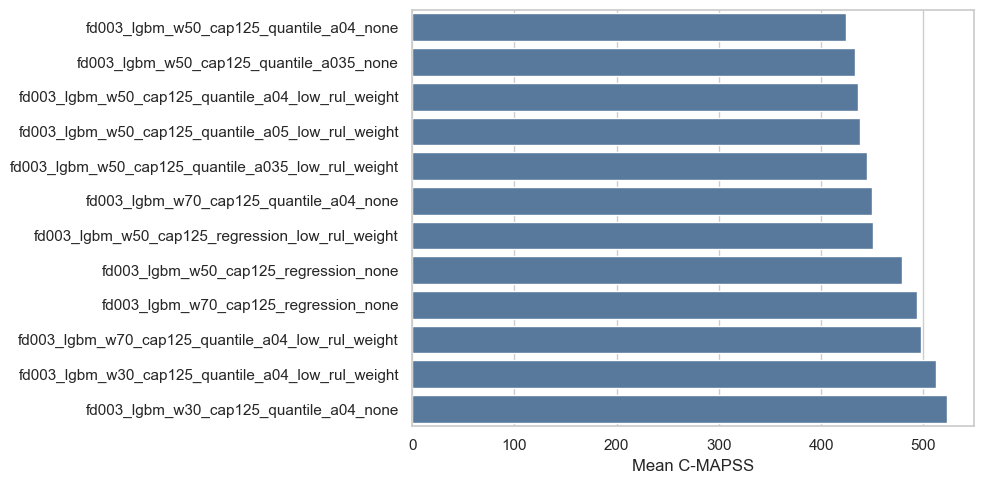

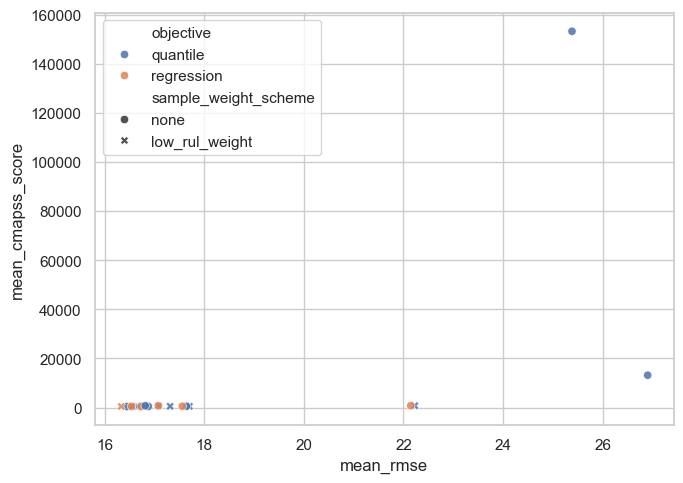

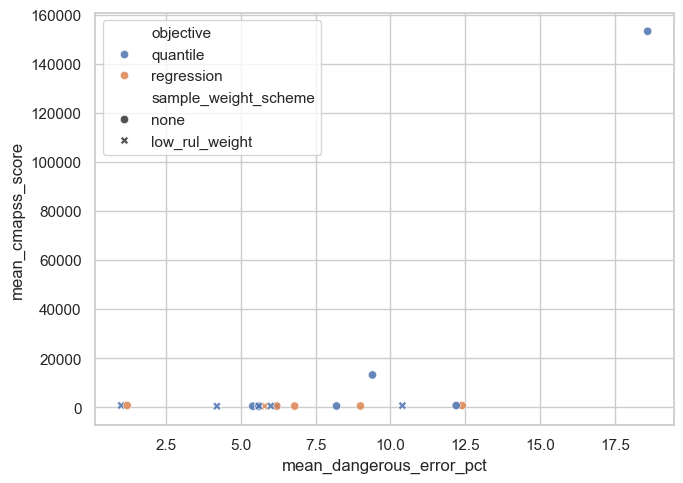

In [5]:
top = summary.head(12).copy()
plt.figure(figsize=(10, 5))
sns.barplot(data=top, y='model_name', x='mean_cmapss_score', color='#4C78A8')
plt.xlabel('Mean C-MAPSS')
plt.ylabel('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fd003_short_tuning_top_models_cmapss.png', dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=summary, x='mean_rmse', y='mean_cmapss_score', hue='objective', style='sample_weight_scheme', alpha=0.85)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fd003_short_tuning_rmse_vs_cmapss.png', dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=summary, x='mean_dangerous_error_pct', y='mean_cmapss_score', hue='objective', style='sample_weight_scheme', alpha=0.85)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fd003_short_tuning_dangerous_vs_cmapss.png', dpi=150)
plt.show()
plt.close()


## Interpretacion

In [6]:
base_cmapss = comparison.loc[comparison['approach'] == 'FD001_transfer_baseline', 'mean_cmapss_score'].iloc[0]
best_cmapss = comparison.loc[comparison['approach'] == 'FD003_short_tuning_best', 'mean_cmapss_score'].iloc[0]
base_rmse = comparison.loc[comparison['approach'] == 'FD001_transfer_baseline', 'mean_rmse'].iloc[0]
best_rmse = comparison.loc[comparison['approach'] == 'FD003_short_tuning_best', 'mean_rmse'].iloc[0]
base_danger = comparison.loc[comparison['approach'] == 'FD001_transfer_baseline', 'mean_dangerous_error_pct'].iloc[0]
best_danger = comparison.loc[comparison['approach'] == 'FD003_short_tuning_best', 'mean_dangerous_error_pct'].iloc[0]
text = f'''FD003 - Short tuning interpretation

Se hizo tuning corto usando solo train_FD003, separacion por motores completos y cortes artificiales. No se uso test oficial.

Mejor candidato: {best['model_name']}
window_size={int(best['window_size'])}, rul_cap={int(best['rul_cap'])}, objective={best['objective']}, alpha={best['alpha']}, sample_weight_scheme={best['sample_weight_scheme']}.

Comparado contra el baseline transferido desde FD001:
- C-MAPSS: {base_cmapss:.3f} -> {best_cmapss:.3f}.
- RMSE: {base_rmse:.3f} -> {best_rmse:.3f}.
- Dangerous error %: {base_danger:.3f}% -> {best_danger:.3f}%.

La seleccion prioriza C-MAPSS promedio, manteniendo dangerous error y RMSE como criterios secundarios. Esta etapa no cambia todavia el modelo final del proyecto: deja un candidato FD003 especifico para comparar contra features sensibles y pseudo-clusters.
'''
path = NOTES_DIR / 'fd003_short_tuning_interpretation.txt'
path.write_text(text, encoding='utf-8')
print(path)
print(text)


C:\Users\lauta\OneDrive\Escritorio\ML\TPF-ML\notas\FD003\fd003_short_tuning_interpretation.txt
FD003 - Short tuning interpretation

Se hizo tuning corto usando solo train_FD003, separacion por motores completos y cortes artificiales. No se uso test oficial.

Mejor candidato: fd003_lgbm_w50_cap125_quantile_a04_none
window_size=50, rul_cap=125, objective=quantile, alpha=0.4, sample_weight_scheme=none.

Comparado contra el baseline transferido desde FD001:
- C-MAPSS: 424.430 -> 424.430.
- RMSE: 16.449 -> 16.449.
- Dangerous error %: 5.600% -> 5.600%.

La seleccion prioriza C-MAPSS promedio, manteniendo dangerous error y RMSE como criterios secundarios. Esta etapa no cambia todavia el modelo final del proyecto: deja un candidato FD003 especifico para comparar contra features sensibles y pseudo-clusters.

